# PIX por Chat com OpenAI Agents SDK

### Cenário

O Banco Aurora quer disponibilizar um assistente bancário conversacional. O cliente poderá escrever mensagens como:

- “Qual é meu saldo?”

- “Cadastre o João. A chave PIX dele é joao@gmail.com.”

- “Faça um PIX de R$ 50 para o João.”

- “Quanto eu já transferi hoje?”

O sistema deverá entender a intenção do usuário, consultar os dados disponíveis e delegar a tarefa para agentes especializados.

O PIX será totalmente simulado. Nenhuma transação bancária real será realizada.

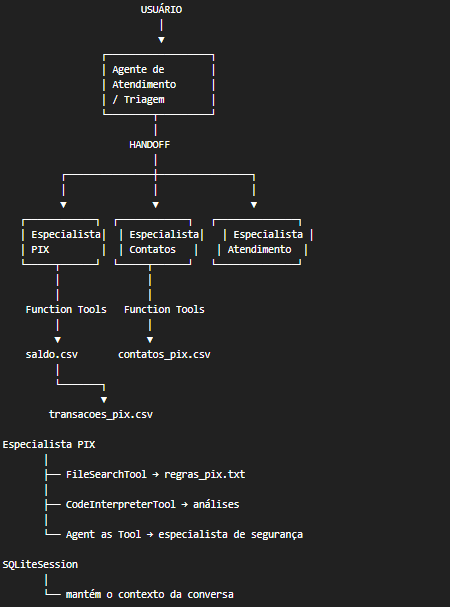

## 2. Estrutura dos arquivos

banco_pix/

│

├── saldo.csv

├── contatos_pix.csv

├── transacoes_pix.csv

└── regras_pix.txt

## 3. Criando os dados iniciais

In [ ]:
import pandas as pd
from pathlib import Path

pd.DataFrame([
    {
        "id_cliente": 1,
        "nome": "Jose",
        "saldo": 1500.00
    }
]).to_csv("saldo.csv", index=False)


pd.DataFrame([
    {
        "id_cliente": 1,
        "nome_contato": "Ana",
        "chave_pix": "ana@email.com"
    },
    {
        "id_cliente": 1,
        "nome_contato": "Carlos",
        "chave_pix": "11999999999"
    }
]).to_csv("contatos_pix.csv", index=False)


pd.DataFrame(
    columns=[
        "id_transacao",
        "id_cliente",
        "destinatario",
        "chave_pix",
        "valor",
        "data",
    ]
).to_csv("transacoes_pix.csv", index=False)

## 4. Function Tools

Aqui está a parte mais importante do projeto.

O LLM não deve editar os CSVs diretamente.

As operações bancárias são implementadas como funções Python controladas.

In [ ]:
!pip install openai-agents

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.7/41.7 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.4/169.4 kB 14.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 357.9/357.9 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.7/69.7 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 19.7 MB/s eta 0:00:00
  Attempting uninstall: openai
    Found existing installation: openai 2.54.0
    Uninstalling openai-2.54.0:
      Successfully uninstalled openai-2.54.0


In [ ]:
from agents import function_tool
import pandas as pd
from datetime import datetime
import uuid

### Tool para consultar saldo

In [ ]:
@function_tool
def consultar_saldo(id_cliente: int = 1) -> dict:
    """Consulta o saldo atual do cliente."""

    df = pd.read_csv("saldo.csv")

    cliente = df[df["id_cliente"] == id_cliente]

    if cliente.empty:
        return {
            "sucesso": False,
            "erro": "Cliente não encontrado."
        }

    saldo = float(cliente.iloc[0]["saldo"])

    return {
        "sucesso": True,
        "saldo": saldo
    }

## 5. Consultando contatos PIX

In [ ]:
@function_tool
def listar_contatos_pix(id_cliente: int = 1) -> list:
    """Lista os contatos PIX cadastrados pelo cliente."""

    df = pd.read_csv("contatos_pix.csv")

    contatos = df[
        df["id_cliente"] == id_cliente
    ]

    return contatos[
        ["nome_contato", "chave_pix"]
    ].to_dict(orient="records")

## 6. Buscar um contato

In [ ]:
@function_tool
def buscar_contato_pix(
    nome: str,
    id_cliente: int = 1
) -> dict:
    """Busca a chave PIX de um contato salvo."""

    df = pd.read_csv("contatos_pix.csv")

    resultado = df[
        (df["id_cliente"] == id_cliente)
        &
        (
            df["nome_contato"]
            .str.lower()
            == nome.lower()
        )
    ]

    if resultado.empty:
        return {
            "encontrado": False,
            "mensagem": "Contato não encontrado."
        }

    contato = resultado.iloc[0]

    return {
        "encontrado": True,
        "nome": contato["nome_contato"],
        "chave_pix": contato["chave_pix"],
    }

## 7. Cadastrar um novo contato

In [ ]:
@function_tool
def cadastrar_contato_pix(
    nome: str,
    chave_pix: str,
    id_cliente: int = 1
) -> dict:
    """
    Cadastra um novo contato PIX.
    """

    df = pd.read_csv("contatos_pix.csv")

    existente = df[
        (df["id_cliente"] == id_cliente)
        &
        (
            df["nome_contato"]
            .str.lower()
            == nome.lower()
        )
    ]

    if not existente.empty:
        return {
            "sucesso": False,
            "erro": "Já existe um contato com esse nome."
        }

    novo = pd.DataFrame([
        {
            "id_cliente": id_cliente,
            "nome_contato": nome,
            "chave_pix": chave_pix
        }
    ])

    df = pd.concat(
        [df, novo],
        ignore_index=True
    )

    df.to_csv(
        "contatos_pix.csv",
        index=False
    )

    return {
        "sucesso": True,
        "nome": nome,
        "chave_pix": chave_pix
    }

## 8. Tool que realiza o PIX

In [ ]:
@function_tool
def realizar_pix(
    destinatario: str,
    chave_pix: str,
    valor: float,
    id_cliente: int = 1
) -> dict:
    """
    Realiza uma transferência PIX simulada.
    """

    if valor <= 0:
        return {
            "sucesso": False,
            "erro": "O valor deve ser maior que zero."
        }

    if valor > 1000:
        return {
            "sucesso": False,
            "erro": "O limite por PIX é R$ 1.000."
        }

    saldos = pd.read_csv("saldo.csv")

    mask = saldos["id_cliente"] == id_cliente

    if not mask.any():
        return {
            "sucesso": False,
            "erro": "Cliente não encontrado."
        }

    saldo_atual = float(
        saldos.loc[mask, "saldo"].iloc[0]
    )

    if saldo_atual < valor:
        return {
            "sucesso": False,
            "erro": "Saldo insuficiente.",
            "saldo": saldo_atual
        }

    # debita
    novo_saldo = saldo_atual - valor

    saldos.loc[
        mask,
        "saldo"
    ] = novo_saldo

    saldos.to_csv(
        "saldo.csv",
        index=False
    )

    # registra transação
    transacoes = pd.read_csv(
        "transacoes_pix.csv"
    )

    nova_transacao = pd.DataFrame([
        {
            "id_transacao": str(uuid.uuid4()),
            "id_cliente": id_cliente,
            "destinatario": destinatario,
            "chave_pix": chave_pix,
            "valor": valor,
            "data": datetime.now().isoformat()
        }
    ])

    transacoes = pd.concat(
        [transacoes, nova_transacao],
        ignore_index=True
    )

    transacoes.to_csv(
        "transacoes_pix.csv",
        index=False
    )

    return {
        "sucesso": True,
        "destinatario": destinatario,
        "valor": valor,
        "saldo_anterior": saldo_atual,
        "saldo_atual": novo_saldo
    }

## 9. Agente especialista em contatos

In [ ]:
from agents import Agent

In [ ]:
agente_contatos = Agent(
    name="Especialista em contatos PIX",

    handoff_description=(
        "Use este agente para cadastrar, consultar "
        "ou procurar contatos PIX."
    ),

    instructions="""
              Você é o especialista em contatos PIX do Banco Aurora.

              Você pode:

              - listar contatos;
              - localizar contatos pelo nome;
              - cadastrar novos contatos.

              Nunca invente uma chave PIX.

              Se faltar nome ou chave PIX para um cadastro,
              pergunte ao usuário.

              Use obrigatoriamente as ferramentas disponíveis
              para consultar ou alterar contatos.
    """,

    tools=[
        listar_contatos_pix,
        buscar_contato_pix,
        cadastrar_contato_pix,
    ],

    model="gpt-4o-mini",
)

## 10. Agente de segurança

In [ ]:
agente_seguranca = Agent(
    name="Analista de segurança PIX",

    instructions="""
Analise solicitações de PIX.

Verifique se existem informações inconsistentes
ou potencialmente perigosas.

Informe objetivamente se a operação parece adequada
para continuar.

Não realize nenhuma transferência.
""",

    model="gpt-4o-mini",
)

## 11. FileSearchTool para regras do PIX

In [ ]:
from pathlib import Path

regras = Path("regras_pix.txt")

regras.write_text(
    """
REGRAS PIX - BANCO AURORA

- O valor mínimo de uma transferência é maior que zero.
- O limite deste ambiente didático é R$ 1.000 por PIX.
- O cliente precisa possuir saldo suficiente.
- O destinatário deve possuir uma chave PIX.
- O PIX deste projeto é apenas uma simulação.
""",
    encoding="utf-8"
)

276

In [ ]:
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

vector_store = client.vector_stores.create(
    name="Regras PIX Banco Aurora"
)

with regras.open("rb") as arquivo:
    arquivo_indexado = (
        client.vector_stores.files.upload_and_poll(
            vector_store_id=vector_store.id,
            file=arquivo,
        )
    )

print(vector_store.id)

vs_6a9b6466f0308191a930ce07988864e2


## 12. Especialista em PIX

In [ ]:
from agents import FileSearchTool

In [ ]:
agente_pix = Agent(
    name="Especialista em PIX",

    handoff_description=(
        "Use para transferência PIX, saldo, "
        "histórico PIX ou dúvidas sobre regras PIX."
    ),

    instructions="""
Você é o especialista PIX do Banco Aurora.

Sua responsabilidade é ajudar o cliente com PIX.

Para transferências:

1. identifique destinatário;
2. identifique o valor;
3. encontre a chave PIX usando as ferramentas;
4. consulte as regras quando necessário;
5. consulte o agente de segurança;
6. somente então utilize realizar_pix.

Nunca invente:
- saldo;
- contatos;
- chaves PIX;
- transferências.

Se uma informação necessária estiver faltando,
pergunte ao usuário.

As transferências são apenas simulações didáticas.
""",

    tools=[
        consultar_saldo,
        buscar_contato_pix,
        realizar_pix,

        FileSearchTool(
            vector_store_ids=[
                vector_store.id
            ],
            max_num_results=5,
        ),

        agente_seguranca.as_tool(
            tool_name="consultar_seguranca_pix",
            tool_description=(
                "Analisa uma operação PIX antes "
                "da sua execução."
            ),
        ),
    ],

    model="gpt-4o-mini",
)

## 13. CodeInterpreterTool

Também podemos criar um agente especializado em analisar o histórico financeiro.

Por exemplo:

- “Quanto eu transferi por PIX?”

- “Qual pessoa recebeu mais PIX?”

- “Qual foi meu PIX médio?”

- “Faça um resumo das minhas transferências.”

Nesse caso, CodeInterpreterTool faz muito sentido.

Primeiro colocamos o CSV em um container.

In [ ]:
from openai import OpenAI

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))

container = client.containers.create(
    name="historico-pix"
)

with open(
    "transacoes_pix.csv",
    "rb"
) as arquivo:

    client.containers.files.create(
        container_id=container.id,
        file=arquivo
    )

In [ ]:
from agents import CodeInterpreterTool, Runner
import os

os.environ['OPENAI_API_KEY'] = userdata.get('OPENAI_API_KEY')

agente_analista = Agent(
    name="Analista financeiro",

    handoff_description=(
        "Use para análises, estatísticas e perguntas "
        "sobre o histórico de transferências PIX."
    ),

    instructions="""
Analise o arquivo transacoes_pix.csv utilizando
Python e pandas.

Não invente dados.

Utilize Code Interpreter sempre que forem
necessários cálculos ou agregações.
""",

    tools=[
        CodeInterpreterTool(
            tool_config={
                "type": "code_interpreter",
                "container": container.id,
            }
        )
    ],

    model="gpt-4o-mini",
)

In [ ]:
resultado = await Runner.run(
    agente_analista,
    """
    Analise minhas transferências PIX.

    Informe:
    1. total transferido;
    2. valor médio;
    3. maior PIX;
    4. destinatário que mais recebeu dinheiro.
    """
)

print(resultado.final_output)

O arquivo `transacoes_pix.csv` está vazio, sem nenhum dado registrado. Não há informações sobre transações, como valores ou destinatários, para realizar a análise solicitada.

Se você tiver outro arquivo ou mais informações, por favor, envie para que eu possa ajudá-lo.


## 14. Handoff — Agente de atendimento

In [ ]:
agente_atendimento = Agent(
    name="Atendente Banco Aurora",

    instructions="""
Você é o atendente virtual do Banco Aurora.

Identifique a intenção do cliente e transfira
o atendimento para o especialista adequado.

Use:

- Especialista em PIX para pagamentos e saldo;
- Especialista em contatos para cadastro de contatos;
- Analista financeiro para análises do histórico.

Não tente executar tarefas que pertencem
aos especialistas.
""",

    handoffs=[
        agente_pix,
        agente_contatos,
        agente_analista,
    ],

    model="gpt-4o-mini",
)

## 15. Primeiro teste

In [ ]:
from agents import Runner

resultado = await Runner.run(
    agente_atendimento,
    "Quanto dinheiro eu tenho? so client 1"
)

print(resultado.final_output)

print(
    "Agente que concluiu:",
    resultado.last_agent.name
)

Você tem R$ 1.500,00 disponíveis na sua conta. Se precisar de mais alguma coisa relacionada ao PIX, é só avisar!
Agente que concluiu: Especialista em PIX


## 16. Sessions — memória da conversa

In [ ]:
from agents import SQLiteSession

sessao = SQLiteSession(
    "cliente_1_banco_aurora"
)

In [ ]:
resultado = await Runner.run(
    agente_atendimento,
    "Quero fazer um PIX para a Ana.",
    session=sessao,
)

print(resultado.final_output)

Para prosseguir com a transferência PIX para a Ana, preciso das seguintes informações:

1. **Valor** da transferência.
2. **Chave PIX** da Ana (se não souber, posso ajudar a encontrá-la).

Por favor, forneça essas informações.


In [ ]:
resultado = await Runner.run(
    agente_atendimento,
    "50 reais",
    session=sessao,
)

print(resultado.final_output)

A solicitação de transferência foi verificada e está adequada para prosseguir. Caso você tenha certeza das informações, podemos seguir com a simulação da transferência.

Por favor, confirme se deseja continuar com a transferência de R$ 50,00 para Ana usando a chave PIX **ana@email.com**.


In [ ]:
import gradio as gr
import pandas as pd

from agents import Runner, SQLiteSession


# ============================================================
# SESSION
# ============================================================

session = SQLiteSession(
    "cliente_1_banco_aurora",
    "banco_aurora_sessions.db",
)


# ============================================================
# FUNÇÕES AUXILIARES
# ============================================================

def obter_saldo():
    df = pd.read_csv("saldo.csv")

    cliente = df[
        df["id_cliente"] == 1
    ]

    if cliente.empty:
        return "R$ 0,00"

    saldo = float(
        cliente.iloc[0]["saldo"]
    )

    return f"R$ {saldo:,.2f}".replace(
        ",", "X"
    ).replace(
        ".", ","
    ).replace(
        "X", "."
    )


def obter_contatos():
    df = pd.read_csv(
        "contatos_pix.csv"
    )

    df = df[
        df["id_cliente"] == 1
    ]

    if df.empty:
        return "Nenhum contato cadastrado."

    texto = ""

    for _, contato in df.iterrows():

        texto += (
            f"**{contato['nome_contato']}**  \n"
            f"{contato['chave_pix']}  \n\n"
        )

    return texto


# CHAT

async def conversar_com_banco(
    message,
    history
):

    try:

        resultado = await Runner.run(
            agente_atendimento,
            message,
            session=session,
        )

        return resultado.final_output

    except Exception as e:

        return (
            "Erro durante o atendimento:\n\n"
            f"`{str(e)}`"
        )


# INTERFACE

with gr.Blocks() as demo:

    gr.Markdown(
        """
        # 🏦 Banco Aurora

        ### Assistente Bancário com OpenAI Agents SDK

        Converse naturalmente com o banco para
        consultar saldo, cadastrar contatos e
        realizar PIX.
        """
    )

    with gr.Row():

        # COLUNA DO CHAT

        with gr.Column(scale=3):

            chatbot = gr.Chatbot(
                height=500,
                placeholder=(
                    "Olá! Sou o assistente do Banco Aurora.\n\n"
                    "Como posso ajudar?"
                ),
            )

            gr.ChatInterface(
                fn=conversar_com_banco,

                chatbot=chatbot,

                examples=[
                    "Qual é meu saldo?",
                    "Quais contatos PIX eu tenho?",
                    "Quero fazer um PIX para Ana.",
                    "Cadastre João como contato PIX.",
                    "Quanto já transferi?",
                ],
            )

        # COLUNA DE INFORMAÇÕES

        with gr.Column(scale=1):

            gr.Markdown(
                "### 👤 Minha conta"
            )

            saldo_display = gr.Textbox(
                label="Saldo atual",
                value=obter_saldo(),
                interactive=False,
            )

            gr.Markdown(
                "### 📱 Contatos PIX"
            )

            contatos_display = gr.Markdown(
                obter_contatos()
            )

            atualizar = gr.Button(
                "🔄 Atualizar dados"
            )

            atualizar.click(
                fn=obter_saldo,
                outputs=saldo_display,
            )

            atualizar.click(
                fn=obter_contatos,
                outputs=contatos_display,
            )


demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ac58b709c256fa94fd.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
